# FitBuddy AI — Squat Form EDA
Exploratory analysis of the Reddit squat form dataset collected and audited via the SAM3 pipeline.

In [1]:
import os
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#111214',
    'axes.facecolor':   '#161820',
    'axes.edgecolor':   '#2d3f6b',
    'axes.labelcolor':  '#f0ece4',
    'xtick.color':      '#8a9bb5',
    'ytick.color':      '#8a9bb5',
    'text.color':       '#f0ece4',
    'grid.color':       '#2d3f6b',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})

BLUE_LIGHT  = '#7eb8d4'
BLUE_MID    = '#4a6fa5'
BLUE_NAVY   = '#2d3f6b'
GREEN       = '#56c596'
AMBER       = '#e5a14a'
RED         = '#e06c75'
PALETTE     = [BLUE_LIGHT, BLUE_MID, GREEN, AMBER, RED, '#9b59b6', '#1abc9c']

RESULTS_DIR = os.path.join('..', 'squat-frontend', 'data', 'reddit', 'results')
print(f'Results directory: {os.path.abspath(RESULTS_DIR)}')

Results directory: c:\Users\User\OneDrive\Documents\AI_Builder_Fitness\squat-frontend\data\reddit\results


In [2]:
# ── Parse all structured_feedback JSONs ──────────────────────────────────────

def strip_fences(text):
    """Mirror of parse_to_dict_safely from few-shot.py"""
    text = text.strip()
    text = re.sub(r'^```(?:json)?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'```$', '', text)
    return text.strip()

records = []

for root, _, files in os.walk(RESULTS_DIR):
    for fname in files:
        if 'structured_feedback' not in fname.lower() or not fname.endswith('.json'):
            continue
        try:
            with open(os.path.join(root, fname), encoding='utf-8') as f:
                blob = json.load(f)

            # Use zero_shot as primary, fall back to rag_augmented
            raw = blob.get('zero_shot') or blob.get('rag_augmented')
            if not raw:
                continue

            data = json.loads(strip_fences(raw))

            # Derive category from folder path
            parts = root.replace('\\', '/').split('/')
            group    = next((p for p in parts if p.startswith('Group_')),    'Unknown').replace('Group_', '').replace('_', ' ')
            subgroup = next((p for p in parts if p.startswith('SubGroup_')), 'Unknown').replace('SubGroup_', '').replace('_', ' ')

            records.append({
                'file':              fname,
                'group':             group,
                'subgroup':          subgroup,
                'exercise':          data.get('exercise', 'unknown').replace('_', ' ').title(),
                'rep_count':         data.get('rep_count'),
                'estimated_load':    data.get('estimated_load', 'unknown'),
                'overall_rating':    data.get('overall_rating'),
                'good_aspects':      [g['aspect'] for g in data.get('good', [])],
                'fault_aspects':     [n['aspect'] for n in data.get('needs_improvement', [])],
                'good_count':        len(data.get('good', [])),
                'fault_count':       len(data.get('needs_improvement', [])),
            })
        except Exception:
            continue

df = pd.DataFrame(records)
print(f'Total videos parsed: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total videos parsed: 300
Columns: ['file', 'group', 'subgroup', 'exercise', 'rep_count', 'estimated_load', 'overall_rating', 'good_aspects', 'fault_aspects', 'good_count', 'fault_count']


,file,group,subgroup,exercise,rep_count,estimated_load,overall_rating,good_aspects,fault_aspects,good_count,fault_count
0,102x10 Front Squat 73kg_structured_feedback.json,General Training,Front Squats,Barbell Front Squat,10,heavy,3,[Depth],"[Equipment Safety, Lumbar Stability, Upper Bod...",1,4
1,180kg front squat 75kg_structured_feedback.json,General Training,Front Squats,Barbell Back Squat,1,heavy,8,"[Depth, Bar Path]","[Heel Stability, Upper Body]",2,2
2,200kg front squat_structured_feedback.json,General Training,Front Squats,Barbell Back Squat,1,heavy,8,"[Range of Motion, Heel Stability, Knee Tracking]",[Chest Position],3,1
3,200kg Pause Front Squat_structured_feedback.json,General Training,Front Squats,Barbell Back Squat,1,heavy,8,"[Depth, Core Stability, Bar Path]","[Knee Stability, Heel Stability]",3,2
4,205kg front squat at 17 years old 109kg bodyw_...,General Training,Front Squats,Barbell Back Squat,1,heavy,8,"[Foot stability, Depth, Safety]","[Lumbar stability, Bar path]",3,2


## 1. Dataset Overview

In [3]:
print('=== DATASET SUMMARY ===')
print(f"Total videos analysed : {len(df)}")
print(f"Unique exercise types : {df['exercise'].nunique()}")
print(f"Avg overall rating    : {df['overall_rating'].mean():.2f} / 10")
print(f"Avg rep count         : {df['rep_count'].mean():.1f}")
print(f"Avg faults per video  : {df['fault_count'].mean():.1f}")
print(f"\nGroups:")
print(df['group'].value_counts().to_string())

=== DATASET SUMMARY ===
Total videos analysed : 300
Unique exercise types : 20
Avg overall rating    : 7.69 / 10
Avg rep count         : 3.4
Avg faults per video  : 2.2

Groups:
group
General Training         168
Technical FormCheck       76
Performance PRs           48
Olympic Weightlifting      4
Safety and Fails           4


## 2. Videos per Category

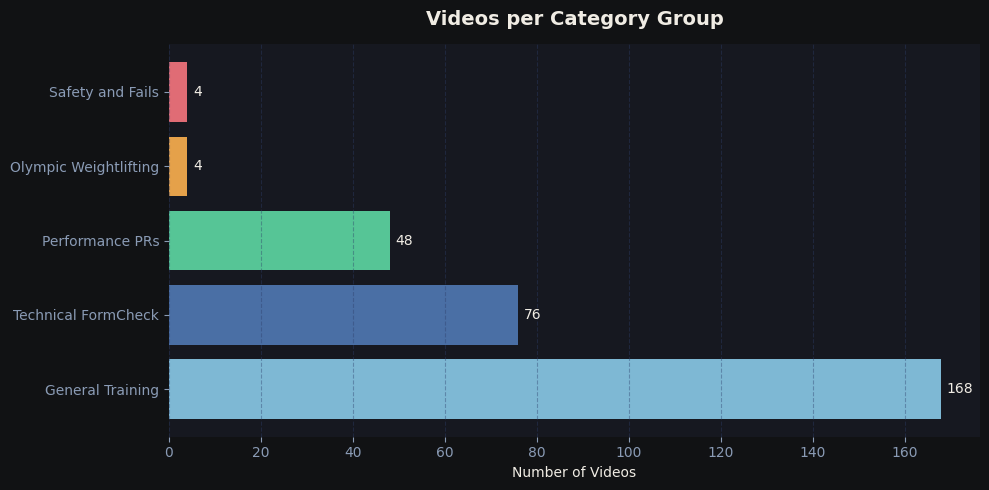

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['group'].value_counts()
bars = ax.barh(counts.index, counts.values, color=PALETTE[:len(counts)], edgecolor='none')
ax.bar_label(bars, padding=4, color='#f0ece4', fontsize=10)
ax.set_title('Videos per Category Group', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Number of Videos')
ax.grid(axis='x')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_1_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Overall Rating Distribution

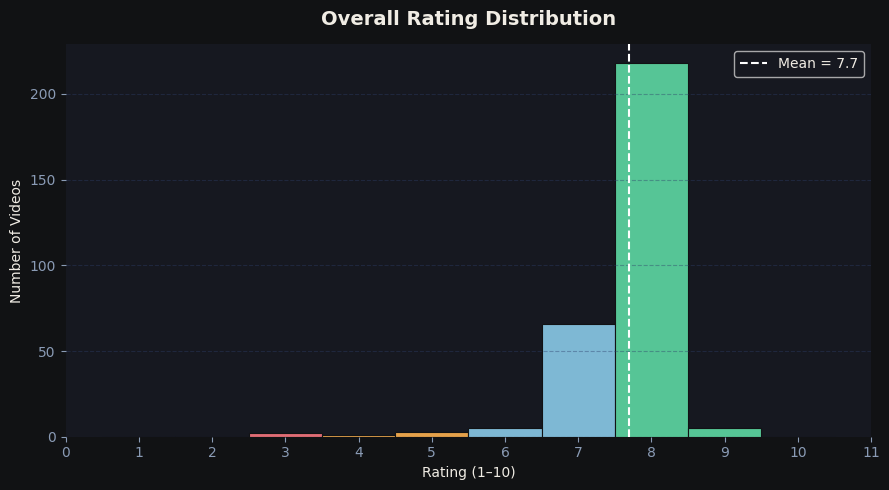

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ratings = df['overall_rating'].dropna()
bins = [i - 0.5 for i in range(1, 12)]
n, _, patches = ax.hist(ratings, bins=bins, edgecolor='#111214', linewidth=0.8)
for patch, val in zip(patches, range(1, 11)):
    if val >= 8:   patch.set_facecolor(GREEN)
    elif val >= 6: patch.set_facecolor(BLUE_LIGHT)
    elif val >= 4: patch.set_facecolor(AMBER)
    else:          patch.set_facecolor(RED)
ax.axvline(ratings.mean(), color='white', linestyle='--', linewidth=1.5, label=f'Mean = {ratings.mean():.1f}')
ax.set_title('Overall Rating Distribution', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Rating (1–10)')
ax.set_ylabel('Number of Videos')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend()
ax.grid(axis='y')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_2_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Most Common Faults

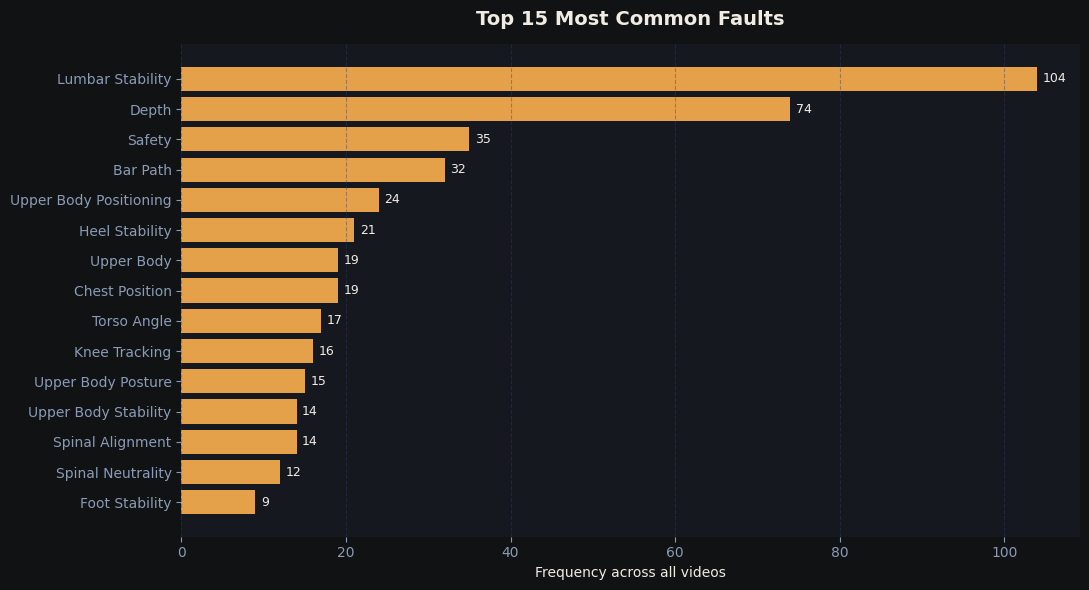

In [6]:
all_faults = [f for faults in df['fault_aspects'] for f in faults]
fault_counts = Counter(all_faults).most_common(15)
labels, values = zip(*fault_counts)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(list(reversed(labels)), list(reversed(values)), color=AMBER, edgecolor='none')
ax.bar_label(bars, padding=4, color='#f0ece4', fontsize=9)
ax.set_title('Top 15 Most Common Faults', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Frequency across all videos')
ax.grid(axis='x')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_3_common_faults.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Most Common Strengths

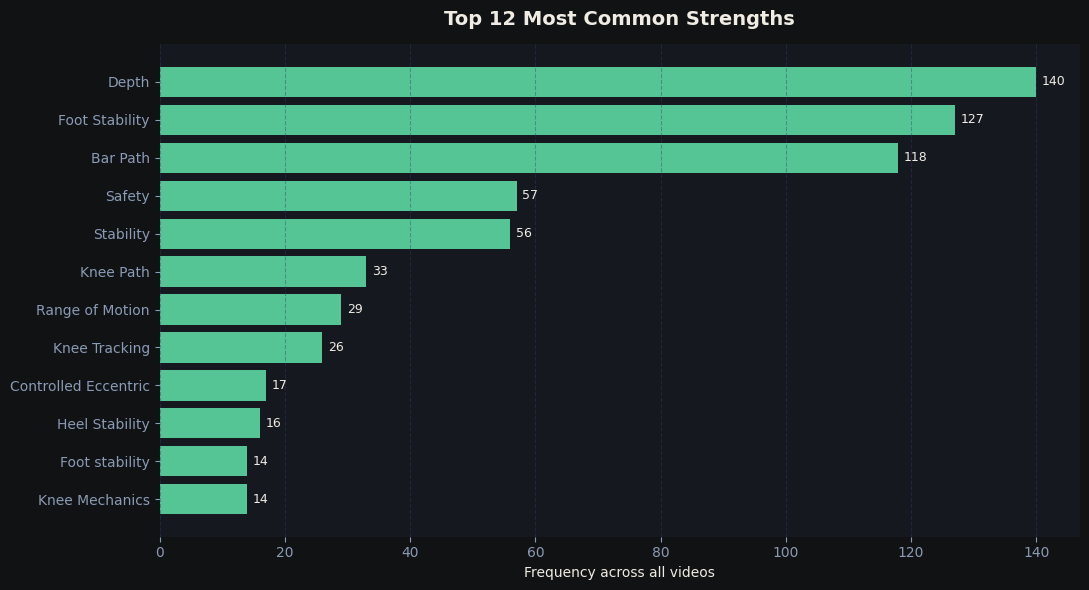

In [7]:
all_good = [g for goods in df['good_aspects'] for g in goods]
good_counts = Counter(all_good).most_common(12)
labels_g, values_g = zip(*good_counts)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(list(reversed(labels_g)), list(reversed(values_g)), color=GREEN, edgecolor='none')
ax.bar_label(bars, padding=4, color='#f0ece4', fontsize=9)
ax.set_title('Top 12 Most Common Strengths', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Frequency across all videos')
ax.grid(axis='x')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_4_common_strengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Load Distribution

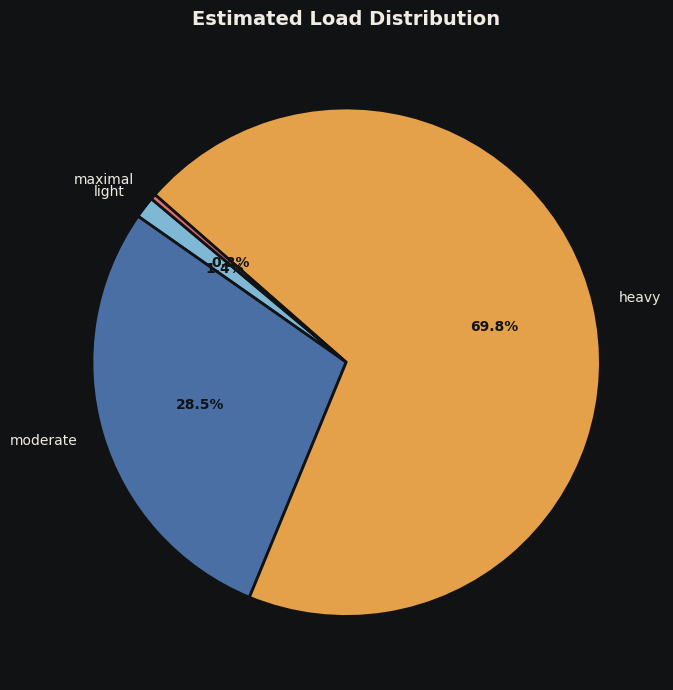

In [8]:
load_order  = ['light', 'moderate', 'heavy', 'maximal']
load_colors = [BLUE_LIGHT, BLUE_MID, AMBER, RED]
load_counts = df['estimated_load'].value_counts().reindex(load_order).fillna(0)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    load_counts,
    labels=load_counts.index,
    autopct='%1.1f%%',
    colors=load_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='#111214', linewidth=2),
)
for t in autotexts: t.set_color('#111214'); t.set_fontweight('bold')
ax.set_title('Estimated Load Distribution', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('chart_5_load_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Rep Count Distribution

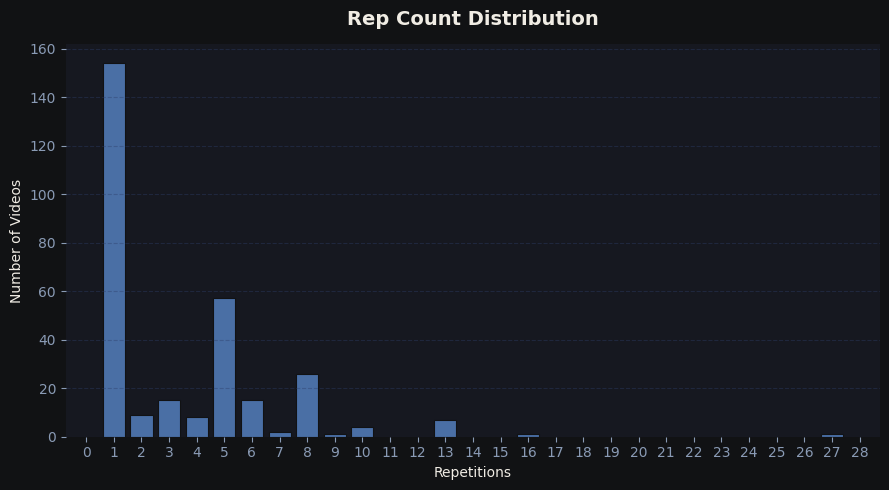

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
reps = df['rep_count'].dropna().astype(int)
rep_counts = reps.value_counts().sort_index()
ax.bar(rep_counts.index, rep_counts.values, color=BLUE_MID, edgecolor='#111214', linewidth=0.8)
ax.set_title('Rep Count Distribution', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Repetitions')
ax.set_ylabel('Number of Videos')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(axis='y')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_6_rep_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Rating vs Load (Box Plot)

C:\Users\User\AppData\Local\Temp\ipykernel_10888\3690833437.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=load_order, patch_artist=True, widths=0.5,


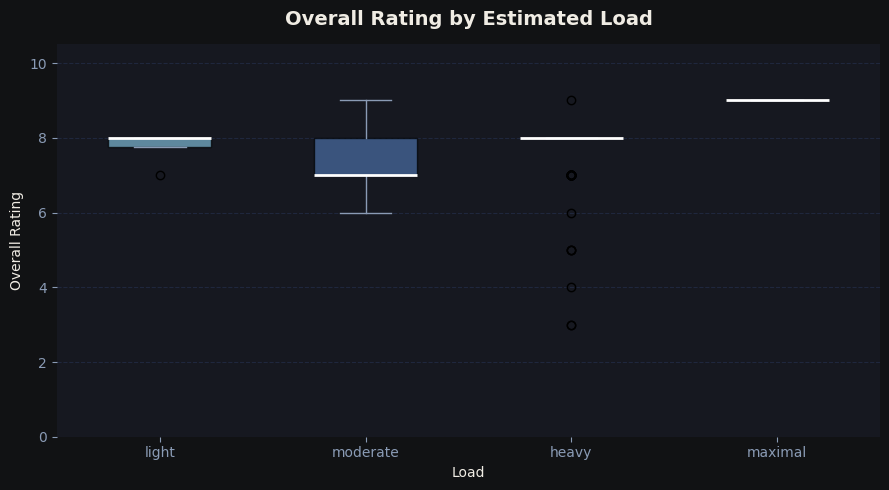

In [10]:
load_order = ['light', 'moderate', 'heavy', 'maximal']
df_load = df[df['estimated_load'].isin(load_order)].copy()
df_load['estimated_load'] = pd.Categorical(df_load['estimated_load'], categories=load_order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 5))
groups = [df_load[df_load['estimated_load'] == l]['overall_rating'].dropna() for l in load_order]
bp = ax.boxplot(groups, labels=load_order, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [BLUE_LIGHT, BLUE_MID, AMBER, RED]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]: item.set_color('#8a9bb5')
ax.set_title('Overall Rating by Estimated Load', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Load')
ax.set_ylabel('Overall Rating')
ax.set_ylim(0, 10.5)
ax.grid(axis='y')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_7_rating_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Exercise Type Breakdown

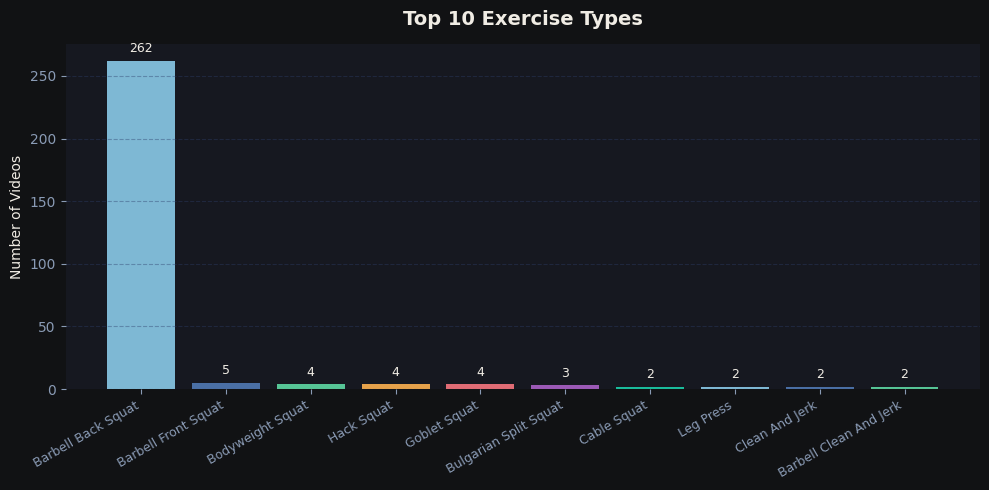


All charts saved as PNG files in the eda/ folder.


In [11]:
ex_counts = df['exercise'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(ex_counts)), ex_counts.values,
              color=[PALETTE[i % len(PALETTE)] for i in range(len(ex_counts))],
              edgecolor='none')
ax.bar_label(bars, padding=4, color='#f0ece4', fontsize=9)
ax.set_xticks(range(len(ex_counts)))
ax.set_xticklabels(ex_counts.index, rotation=30, ha='right', fontsize=9)
ax.set_title('Top 10 Exercise Types', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Number of Videos')
ax.grid(axis='y')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('chart_8_exercise_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll charts saved as PNG files in the eda/ folder.')